In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import colors as mcolors

In [2]:
sns.set_theme(style='dark')
sns.color_palette('cubehelix')
cubehelix_cmap = sns.cubehelix_palette(start=0.5, rot=-0.5, as_cmap=True, dark=0.2, light=0.9)

plt.rcParams.update({
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 12,
    'axes.titlesize': 16,
    'axes.labelsize': 12,
    'figure.figsize': (14, 8),
    'lines.linewidth': 2.5,
    'lines.markersize': 8,
    'font.family': 'sans-serif',
    'axes.prop_cycle': plt.cycler(color=sns.color_palette('cubehelix', 8))
})

In [3]:
df = pd.read_csv('/kaggle/input/datasets/utsab5740/customer-cohort-analysis/sales.csv', low_memory=False)

print('Dataframe shape: ', df.shape)
print('Dataframe columns: ', df.columns)
df.head()

Dataframe shape:  (286392, 33)
Dataframe columns:  Index(['order_id', 'order_date', 'status', 'item_id', 'sku', 'qty_ordered',
       'price', 'discount_amount', 'category', 'payment_method', 'bi_st',
       'cust_id', 'year', 'month', 'ref_num', 'Name Prefix', 'First Name',
       'Middle Initial', 'Last Name', 'Gender', 'age', 'full_name', 'E Mail',
       'Customer Since', 'SSN', 'Phone No. ', 'Place Name', 'County', 'City',
       'State', 'Zip', 'Region', 'User Name'],
      dtype='object')


,order_id,order_date,status,item_id,sku,qty_ordered,price,discount_amount,category,payment_method,...,Customer Since,SSN,Phone No.,Place Name,County,City,State,Zip,Region,User Name
0,100354678,01-10-2020,received,574772,oasis_Oasis-064-36,21,89.9,0.0,Men's Fashion,cod,...,8/22/2006,627-31-5251,405-959-1129,Vinson,Harmon,Vinson,OK,73571,South,jwtitus
1,100354678,01-10-2020,received,574774,Fantastic_FT-48,11,19.0,0.0,Men's Fashion,cod,...,8/22/2006,627-31-5251,405-959-1129,Vinson,Harmon,Vinson,OK,73571,South,jwtitus
2,100354680,01-10-2020,complete,574777,mdeal_DMC-610-8,9,149.9,0.0,Men's Fashion,cod,...,8/22/2006,627-31-5251,405-959-1129,Vinson,Harmon,Vinson,OK,73571,South,jwtitus
3,100354680,01-10-2020,complete,574779,oasis_Oasis-061-36,9,79.9,0.0,Men's Fashion,cod,...,8/22/2006,627-31-5251,405-959-1129,Vinson,Harmon,Vinson,OK,73571,South,jwtitus
4,100367357,13-11-2020,received,595185,MEFNAR59C38B6CA08CD,2,99.9,0.0,Men's Fashion,cod,...,8/22/2006,627-31-5251,405-959-1129,Vinson,Harmon,Vinson,OK,73571,South,jwtitus


#### Анализ пропусков и аномалий в данных

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286392 entries, 0 to 286391
Data columns (total 33 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   order_id         286392 non-null  object 
 1   order_date       286392 non-null  object 
 2   status           286392 non-null  object 
 3   item_id          286392 non-null  int64  
 4   sku              286392 non-null  object 
 5   qty_ordered      286392 non-null  int64  
 6   price            286392 non-null  float64
 7   discount_amount  286392 non-null  float64
 8   category         286392 non-null  object 
 9   payment_method   286392 non-null  object 
 10  bi_st            286392 non-null  object 
 11  cust_id          286392 non-null  int64  
 12  year             286392 non-null  int64  
 13  month            286392 non-null  object 
 14  ref_num          286392 non-null  int64  
 15  Name Prefix      286392 non-null  object 
 16  First Name       286392 non-null  obje

In [5]:
df.describe()

,item_id,qty_ordered,price,discount_amount,cust_id,year,ref_num,age,Zip
count,286392.000000,286392.000000,286392.000000,286392.000000,286392.000000,286392.000000,286392.000000,286392.000000,286392.000000
mean,741664.902131,3.011296,851.385253,70.039427,70048.019054,2020.618778,560853.663395,46.489033,49723.160015
std,95746.031827,4.573837,1741.750751,256.880870,30243.856395,0.485688,255828.418398,16.673288,27597.198873
min,574769.000000,1.000000,0.000000,0.000000,4.000000,2020.000000,111127.000000,18.000000,210.000000
25%,659684.500000,2.000000,49.900000,0.000000,56519.000000,2020.000000,341265.000000,32.000000,26571.750000
50%,742309.000000,2.000000,119.000000,0.000000,74225.500000,2021.000000,564857.000000,47.000000,49316.000000
75%,826124.250000,3.000000,950.000000,18.383050,92357.000000,2021.000000,781086.000000,61.000000,72645.000000
max,905208.000000,501.000000,101262.590000,30213.150000,115326.000000,2021.000000,999981.000000,75.000000,99950.000000


In [6]:
df[df['cust_id'] == 4]

,order_id,order_date,status,item_id,sku,qty_ordered,price,discount_amount,category,payment_method,...,Customer Since,SSN,Phone No.,Place Name,County,City,State,Zip,Region,User Name
52099,100367316,13-11-2020,order_refunded,595097,MEFMUN59ABBE2AC77A7-9,2,199.9,0.00,Men's Fashion,cod,...,01-04-2010,321-11-0416,314-677-4501,Springfield,Greene,Springfield,MO,65809,Midwest,rcdoughty
52100,100372096,25-11-2020,order_refunded,602094,MEFBUY59B7D3AAE94ED-43,2,80.5,0.00,Men's Fashion,cod,...,01-04-2010,321-11-0416,314-677-4501,Springfield,Greene,Springfield,MO,65809,Midwest,rcdoughty
52101,100372096,25-11-2020,order_refunded,602096,BAGALH59E844E6ADDD7,2,40.0,0.00,Beauty & Grooming,cod,...,01-04-2010,321-11-0416,314-677-4501,Springfield,Greene,Springfield,MO,65809,Midwest,rcdoughty
52102,100374843,06-12-2020,complete,606721,MATSAM59DB75ADB2F80,2,1369.9,145.00,Mobiles & Tablets,easypay_voucher,...,01-04-2010,321-11-0416,314-677-4501,Springfield,Greene,Springfield,MO,65809,Midwest,rcdoughty
52103,100376930,13-12-2020,complete,610060,MATSAM59DB75ADB2F80,2,1400.0,230.00,Mobiles & Tablets,easypay_voucher,...,01-04-2010,321-11-0416,314-677-4501,Springfield,Greene,Springfield,MO,65809,Midwest,rcdoughty
52104,100377141,13-12-2020,complete,610336,MEFBNB59FC750A109F3,2,49.9,0.00,Men's Fashion,cod,...,01-04-2010,321-11-0416,314-677-4501,Springfield,Greene,Springfield,MO,65809,Midwest,rcdoughty
52105,100377141,13-12-2020,complete,610337,MEFBNB59FC74FFCBC1B-L,2,24.9,0.00,Men's Fashion,cod,...,01-04-2010,321-11-0416,314-677-4501,Springfield,Greene,Springfield,MO,65809,Midwest,rcdoughty
52106,100377141,13-12-2020,complete,610339,MEFBNB59FC74FDBC09F-L,2,24.9,0.00,Men's Fashion,cod,...,01-04-2010,321-11-0416,314-677-4501,Springfield,Greene,Springfield,MO,65809,Midwest,rcdoughty
52107,100377141,13-12-2020,complete,610341,MEFBNB59FC74FDBC09F-M,2,24.9,0.00,Men's Fashion,cod,...,01-04-2010,321-11-0416,314-677-4501,Springfield,Greene,Springfield,MO,65809,Midwest,rcdoughty
52108,100377220,13-12-2020,complete,610448,MATSAM59DB75ADB2F80,2,1400.0,230.00,Mobiles & Tablets,easypay_voucher,...,01-04-2010,321-11-0416,314-677-4501,Springfield,Greene,Springfield,MO,65809,Midwest,rcdoughty


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
columns = ['order_id', 'order_date', 'status', 'item_id', 'qty_ordered', 'price', 'discount_amount', 'cust_id', 'Customer Since']
df = df[columns]
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [9]:
df['order_date'] = pd.to_datetime(df['order_date'], format='mixed')
df['customer_since'] = pd.to_datetime(df['customer_since'], format='mixed')

In [10]:
df.describe(include='all')

,order_id,order_date,status,item_id,qty_ordered,price,discount_amount,cust_id,customer_since
count,286392,286392,286392,286392.000000,286392.000000,286392.000000,286392.000000,286392.000000,286392
unique,201716,NaN,13,NaN,NaN,NaN,NaN,NaN,NaN
top,100476608,NaN,canceled,NaN,NaN,NaN,NaN,NaN,NaN
freq,43,NaN,112166,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,2021-03-16 10:16:44.005698304,NaN,741664.902131,3.011296,851.385253,70.039427,70048.019054,2007-10-09 10:05:37.283164160
min,NaN,2020-01-10 00:00:00,NaN,574769.000000,1.000000,0.000000,0.000000,4.000000,1978-11-04 00:00:00
25%,NaN,2020-12-24 00:00:00,NaN,659684.500000,2.000000,49.900000,0.000000,56519.000000,2002-08-24 00:00:00
50%,NaN,2021-03-17 00:00:00,NaN,742309.000000,2.000000,119.000000,0.000000,74225.500000,2010-03-22 00:00:00
75%,NaN,2021-06-06 00:00:00,NaN,826124.250000,3.000000,950.000000,18.383050,92357.000000,2015-01-03 00:00:00
max,NaN,2021-12-09 00:00:00,NaN,905208.000000,501.000000,101262.590000,30213.150000,115326.000000,2017-07-28 00:00:00


Данные чистые, при первичном анализе аномалий не выявлено. Однако данные представляют собой конкретные продажи на уровне item_id. Для дальнейшего анализа удобнее перейти на уровень заказов пользователей (order_id).

In [11]:
df['amount_wout_discount'] = df['price'] * df['qty_ordered']
df['amount'] = df['price'] * df['qty_ordered'] - df['discount_amount']

orders = df.groupby('order_id', as_index=False).agg(
    order_date=('order_date', 'min'),
    status=('status', 'min'),
    total_qty=('qty_ordered', 'sum'),
    total_amount_wout_discount=('amount_wout_discount', 'sum'),
    total_discount=('discount_amount', 'sum'),
    total_amount=('amount', 'sum'),
    cust_id=('cust_id', 'min'),
    customer_since=('customer_since', 'min')
)

In [12]:
orders

,order_id,order_date,status,total_qty,total_amount_wout_discount,total_discount,total_amount,cust_id,customer_since
0,100354677,2020-01-10,canceled,6,1467.8,0.0,1467.8,42485,1981-02-04
1,100354678,2020-01-10,received,32,2096.9,0.0,2096.9,60124,2006-08-22
2,100354679,2020-01-10,canceled,4,613.0,0.0,613.0,53620,2010-06-27
3,100354680,2020-01-10,complete,18,2068.2,0.0,2068.2,60124,2006-08-22
4,100354681,2020-01-10,canceled,2,2199.8,0.0,2199.8,56836,1992-04-03
...,...,...,...,...,...,...,...,...,...
201711,100562383,2021-09-30,cod,2,80.0,0.0,80.0,115325,1987-07-25
201712,100562384,2021-09-30,cod,2,99.8,0.0,99.8,115325,1987-07-25
201713,100562385,2021-09-30,cod,2,139.8,0.0,139.8,115320,2000-03-29
201714,100562386,2021-09-30,processing,2,7119.8,0.0,7119.8,115326,2015-01-28


Рассмотрим распределение статусов заказов.

In [13]:
orders['status'].value_counts().sort_values(ascending=False)

status
canceled          85819
complete          64700
received          27850
order_refunded    20666
refund             1358
cod                 874
paid                226
closed               99
pending              43
payment_review       39
processing           20
holded               19
pending_paypal        3
Name: count, dtype: int64

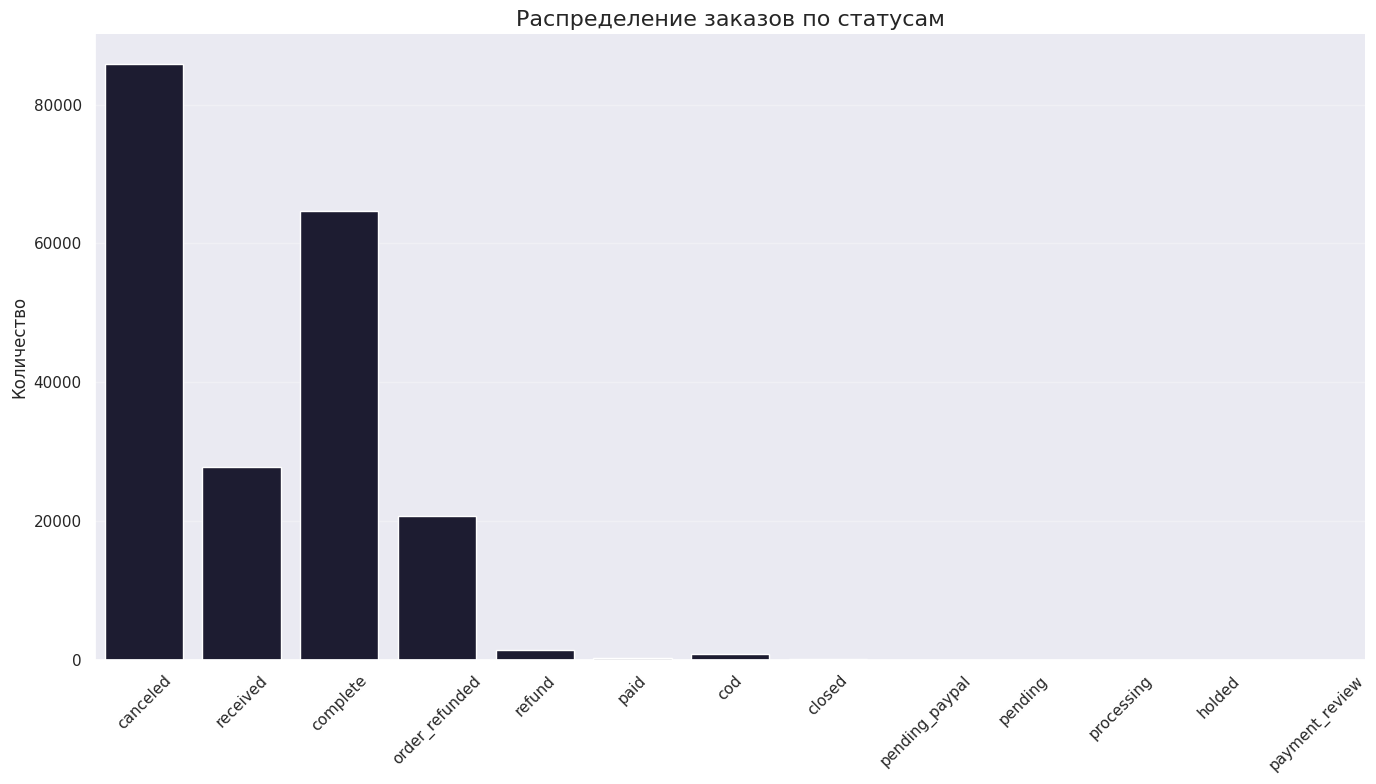

In [14]:
sns.countplot(data=orders, x='status')
plt.title('Распределение заказов по статусам')
plt.ylabel('Количество')
plt.xlabel('')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Подавляющее большинство заказов было отменено, что может говорить о неудовлетворенности пользователей качеством товара, временем доставки, сбоях в системе. 

В дальнейшем мы увидим, что более 50% аудитории делают повторные заказы в тот же день и количество отмененных заказов в таком случае также может быть связано с отменой "импульсивной" покупки.

Посмотрим более детально на аудиторию. Рассчитаем количество пользователей, которые зарегистрировались/совершили первую покупку в определенный год.

In [15]:
complete_orders = orders[orders['status'] == 'complete'].copy()

complete_orders['reg_month'] = complete_orders['customer_since'].dt.to_period('M')
complete_orders['reg_year'] = complete_orders['customer_since'].dt.to_period('Y')

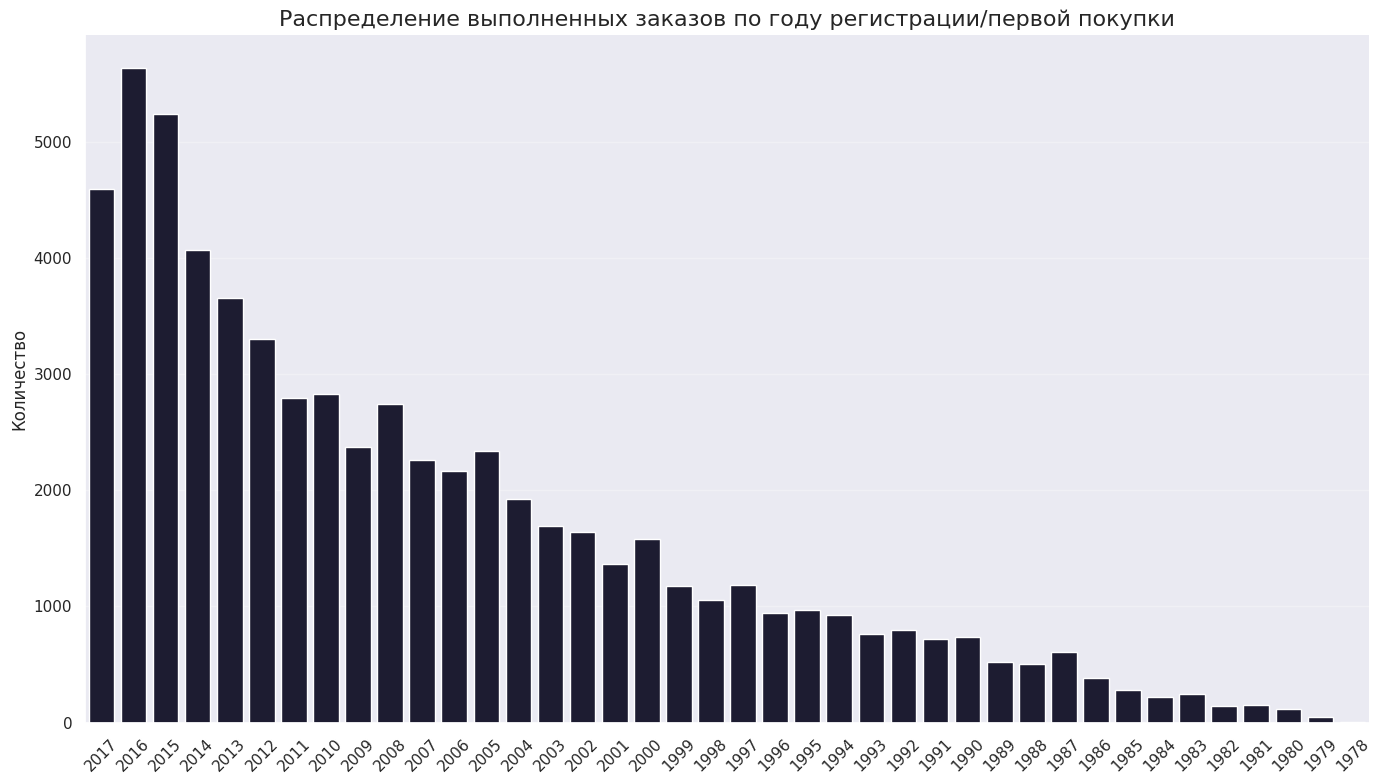

In [16]:
sorted_years = sorted(complete_orders['reg_year'].unique(), reverse=True)

sns.countplot(data=complete_orders, x='reg_year', order=sorted_years)
plt.title('Распределение выполненных заказов по году регистрации/первой покупки')
plt.ylabel('Количество')
plt.xlabel('')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Представленный датасет содержит данные по покупкам в 2020-2021 годах. Исходя из того, что в данных нет пользователей, которые зарегистрировались позднее 2017 года, когортный анализ по новым пользователям не представляется возможным. Данные, скорее всего, представляют базу старых клиентов. В таком случае можно перейти к:
1. когортному анализу по дате первой покупки в представленном периоде;
2. анализу сегментов пользователей;
4. анализу времени до следующей покупки.

#### Когортный анализ по дате первой покупки в периоде

In [17]:
complete_orders['first_order_date'] = complete_orders.groupby('cust_id')['order_date'].transform('min')

complete_orders['order_month'] = complete_orders['order_date'].dt.to_period('M')
complete_orders['cohort_month'] = complete_orders['first_order_date'].dt.to_period('M')

complete_orders['cohort_idx'] = (complete_orders['order_month'] - complete_orders['cohort_month']).apply(lambda x: x.n)
complete_orders['cohort_idx'].isna().sum()

np.int64(0)

In [18]:
cohort_df = complete_orders.groupby(['cohort_month', 'cohort_idx'], as_index=False)['cust_id'] \
            .nunique().sort_values(by=['cohort_month', 'cohort_idx'])

cohort_df_pivot = pd.pivot_table(data=cohort_df, index='cohort_month', columns='cohort_idx', values='cust_id')
cohort_size = cohort_df_pivot.iloc[:, 0]

retention_mtrx = cohort_df_pivot.divide(cohort_size, axis=0).sort_index()

In [19]:
cohort_size.sort_index()

cohort_month
2020-01      149.0
2020-02      137.0
2020-03      159.0
2020-04      103.0
2020-05      148.0
2020-06      469.0
2020-07      217.0
2020-08      179.0
2020-09      175.0
2020-10      808.0
2020-11     1387.0
2020-12    13018.0
2021-01     2059.0
2021-02     1219.0
2021-03     3801.0
2021-04     2396.0
2021-05     1569.0
2021-06      528.0
2021-07      431.0
2021-08      374.0
2021-09      329.0
2021-10      346.0
2021-11      304.0
2021-12      251.0
Freq: M, Name: 0, dtype: float64

В каждой когорте достаточное количество (>100) уникальных активных пользователей для анализа.

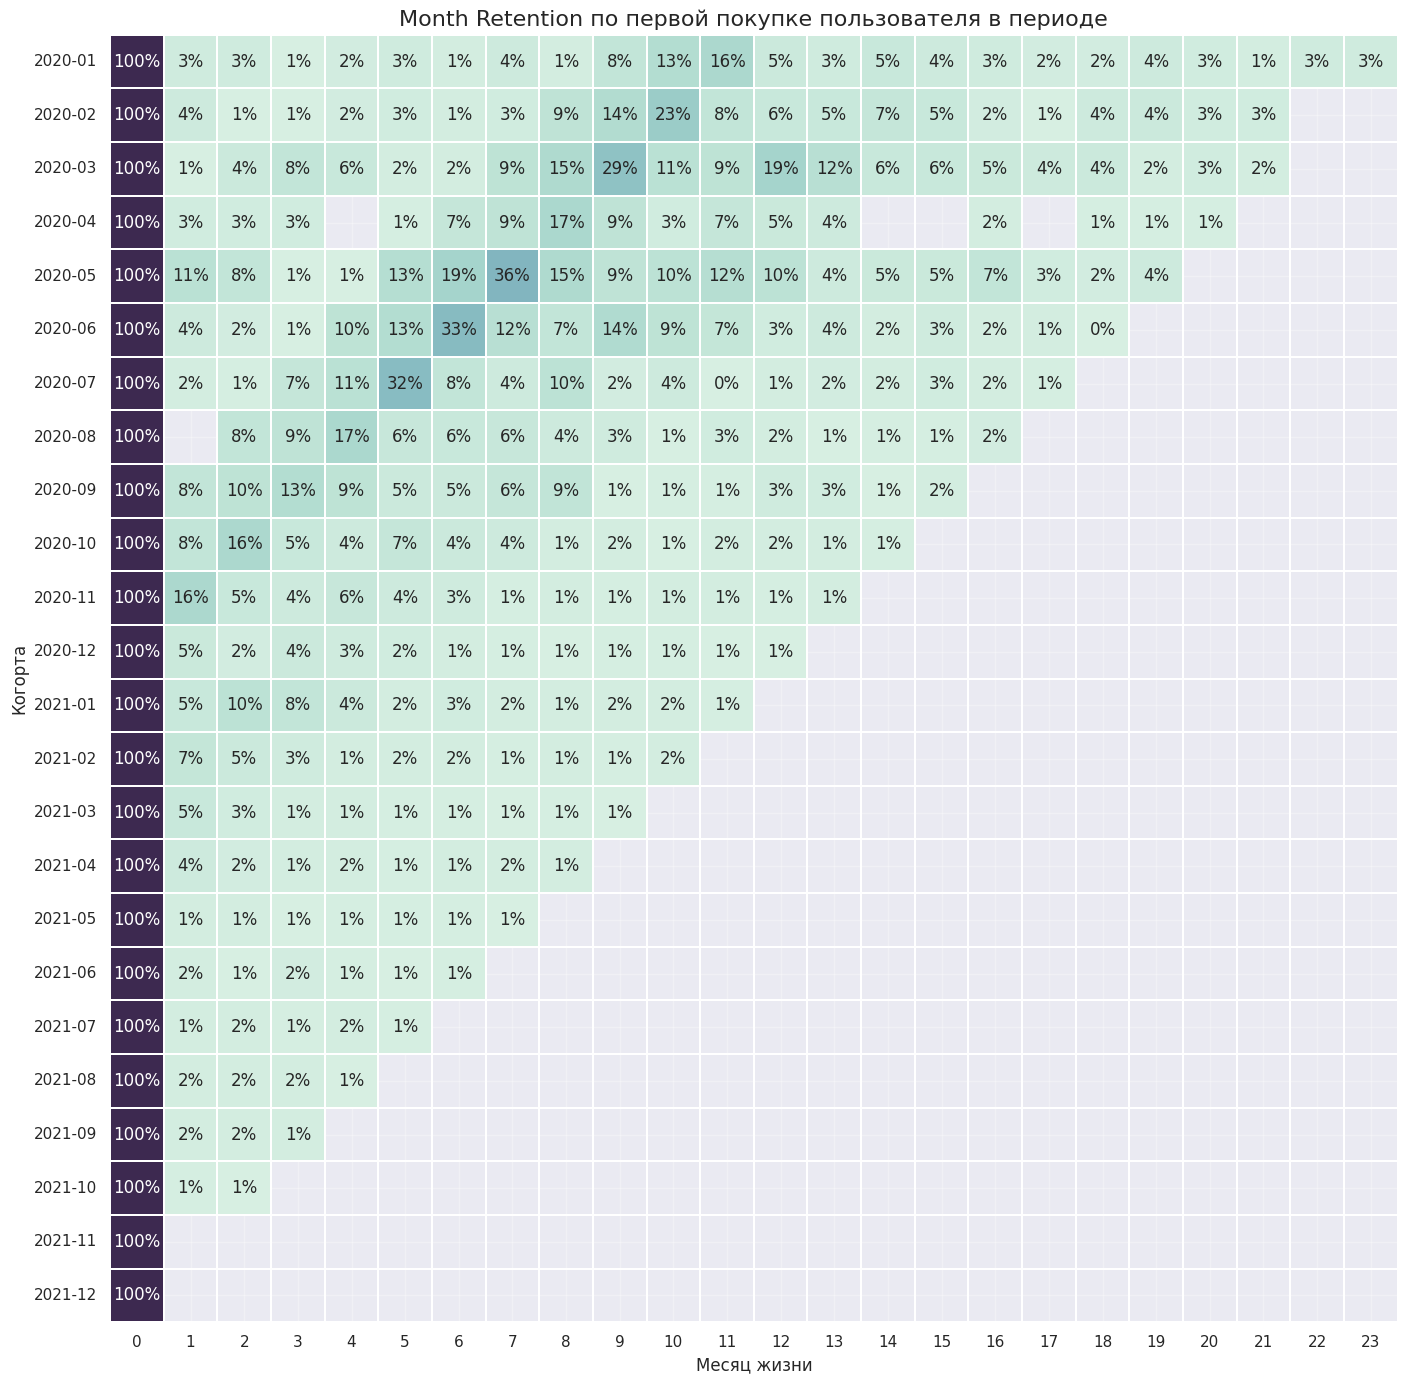

In [20]:
plt.figure(figsize=(16, 14))
sns.heatmap(data=retention_mtrx, annot=True, fmt='.0%', cbar=False, square=True, linewidth=.3, cmap=cubehelix_cmap)
plt.title('Month Retention по первой покупке пользователя в периоде')
plt.ylabel('Когорта')
plt.xlabel('Месяц жизни')
plt.tight_layout()
plt.show()

In [21]:
retention_mtrx_wout_1M = cohort_df_pivot.divide(cohort_size, axis=0).iloc[:, 1:]

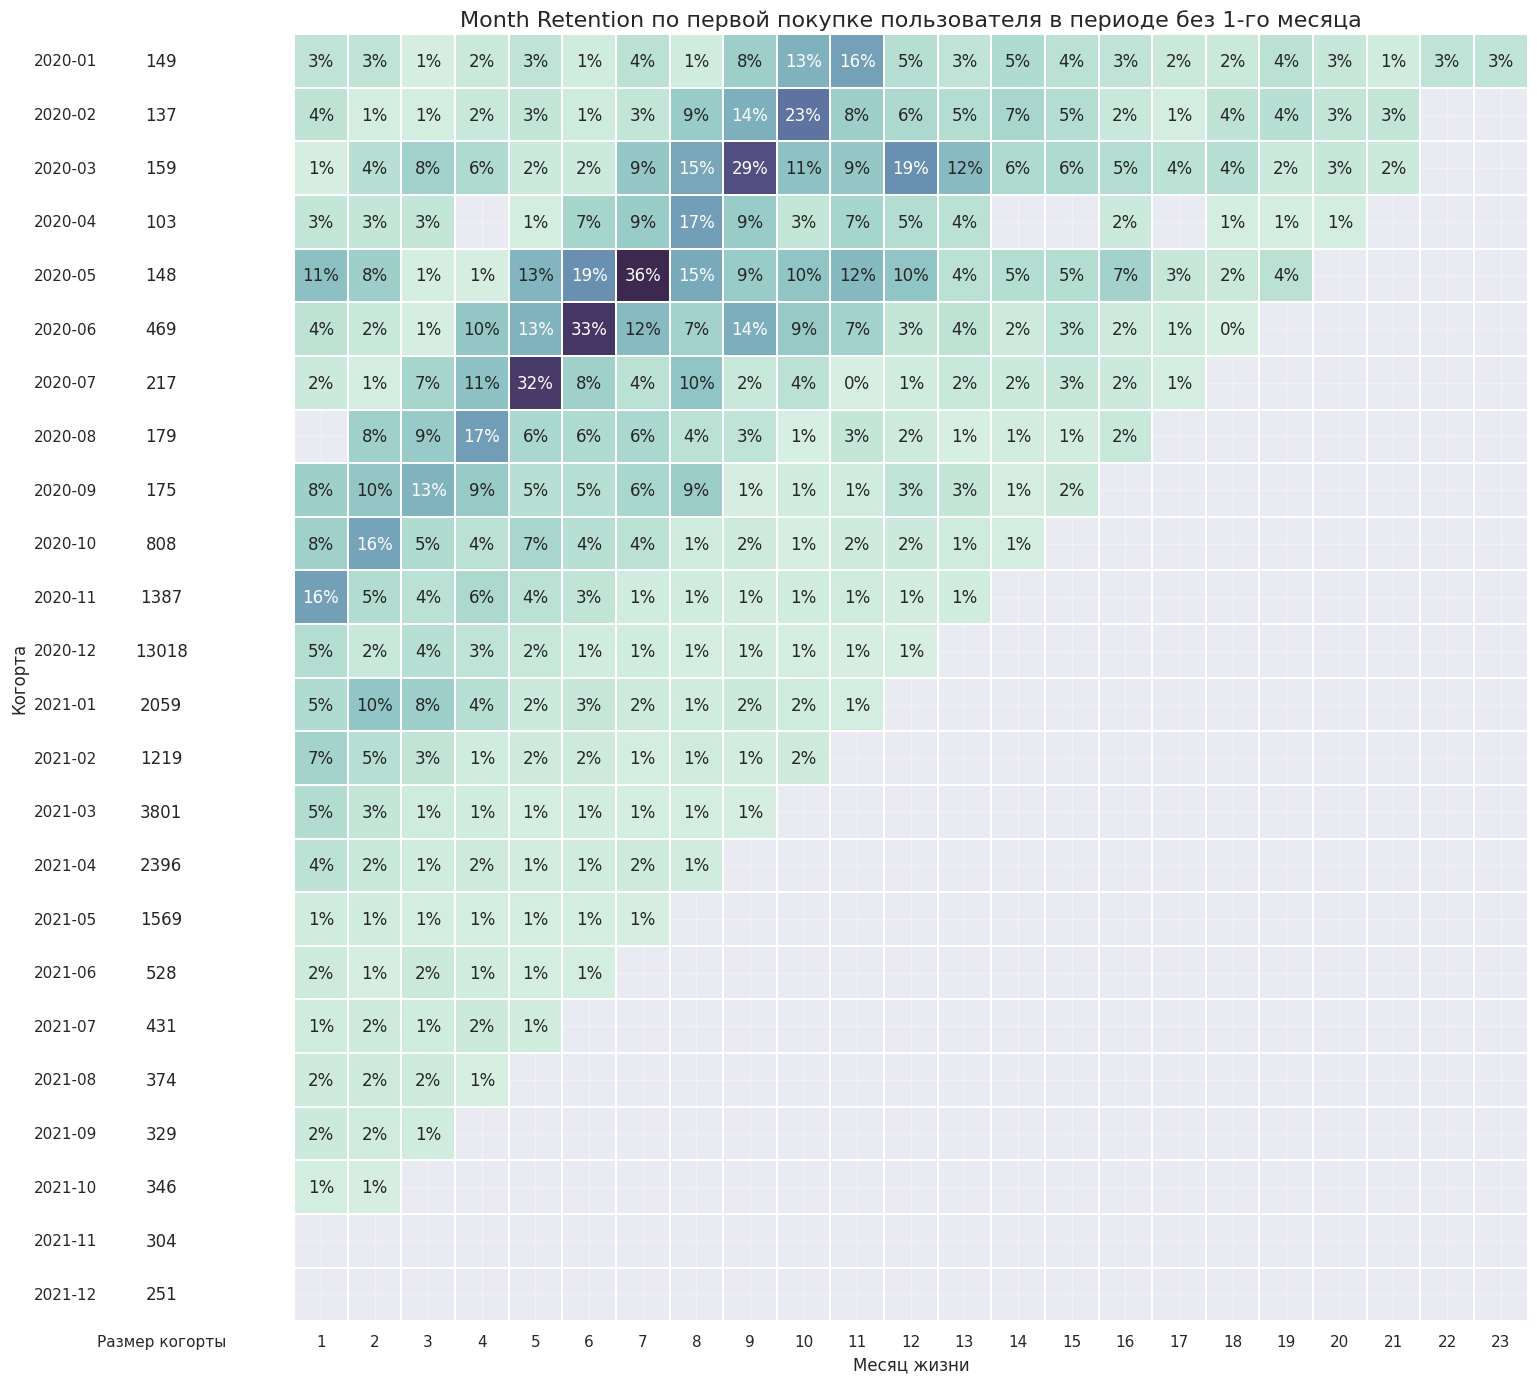

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(16, 14), sharey=True, gridspec_kw={'width_ratios': [1, 13]})

cohort_size_df = pd.DataFrame(cohort_size).rename(columns={0: 'Размер когорты'})

sns.heatmap(cohort_size_df, annot=True, cbar=False, fmt='g', cmap=mcolors.ListedColormap(['white']), ax=ax[0])
ax[0].set_title('')
ax[0].set(ylabel='Когорта')

sns.heatmap(data=retention_mtrx_wout_1M, mask=retention_mtrx_wout_1M.isnull(), annot=True, fmt='.0%', \
            cbar=False, square=True, linewidth=.3, cmap=cubehelix_cmap, ax=ax[1])
ax[1].set_title('Month Retention по первой покупке пользователя в периоде без 1-го месяца')
ax[1].set(xlabel='Месяц жизни', ylabel='')

fig.tight_layout()
plt.show()

In [23]:
retention_mtrx[1].median()*100

3.624733475479744

Медианное значение Retention 1M составляет 3.6%. Это говорит о том, что в сегменте пользователей, зарегистрировавшихся до 2018 года, 96,4% пользователей делают заказ и не возвращаются во второй месяц. Скорее всего, продукт не предполагает регулярных покупок или покупатели не находят достаточной мотивации в постоянных покупках и бизнес соответствует транзакционной модели.

Можно заметить что на диагоналях, соотв. осени-зиме 2020-2021 года Retention показывает заметное увеличение, по сравнению с остальными периодами. Такие показатели могут свидетельствовать о:
1. сезонном спросе (Black Friday, новогодние праздники);
2. сезонности представленных товаров в целом;
3. проведении акции привлечения "старых" клиентов;
4. скидках в данном периоде;

Также можно заметить, что после 05.2021 Retention 1M падает до 1-2% относительно данных до этого периода, что говорит о еще большем оттоке пользователей. 

#### Сегментный анализ по периоду регистрации

Далее посмотрим как ведут себя пользователи в зависимости от периода регистрации. В данных дата регистрации пользователей охватывает 40 лет, поэтому периоды регистрации будут следующие:

- 2013-2017
- 2008-2012
- 2003-2007
- 1998-2002
- 1993-1997
- 1988-1992
- 1978-1987

Здесь мы будем смотреть на всех пользователей, а не только на тех, которые покупали в период с 2020 по 2021 год. Такой выбор обусловлен тем, что хотим смотреть на полную активность пользователя и видеть все статусы, вкл. отмены заказа.

In [24]:
orders['reg_year'] = orders['customer_since'].dt.year.astype(int)
orders['order_month'] = orders['order_date'].dt.to_period('M')

In [25]:
bins = [1978, 1988, 1993, 1998, 2003, 2008, 2013, 2018]
labels = [
    '1978-1987', 
    '1988-1992', 
    '1993-1997', 
    '1998-2002', 
    '2003-2007', 
    '2008-2012', 
    '2013-2017'
]

orders['reg_period'] = pd.cut(orders['reg_year'], bins=bins, labels=labels, right=False)

In [26]:
users_in_period = orders.groupby(['reg_period', 'status'], as_index=False, observed=True)['cust_id'].nunique()
users_in_period = users_in_period[users_in_period['cust_id'] > 10]
sorted_period = sorted(users_in_period['reg_period'].unique(), reverse=True)

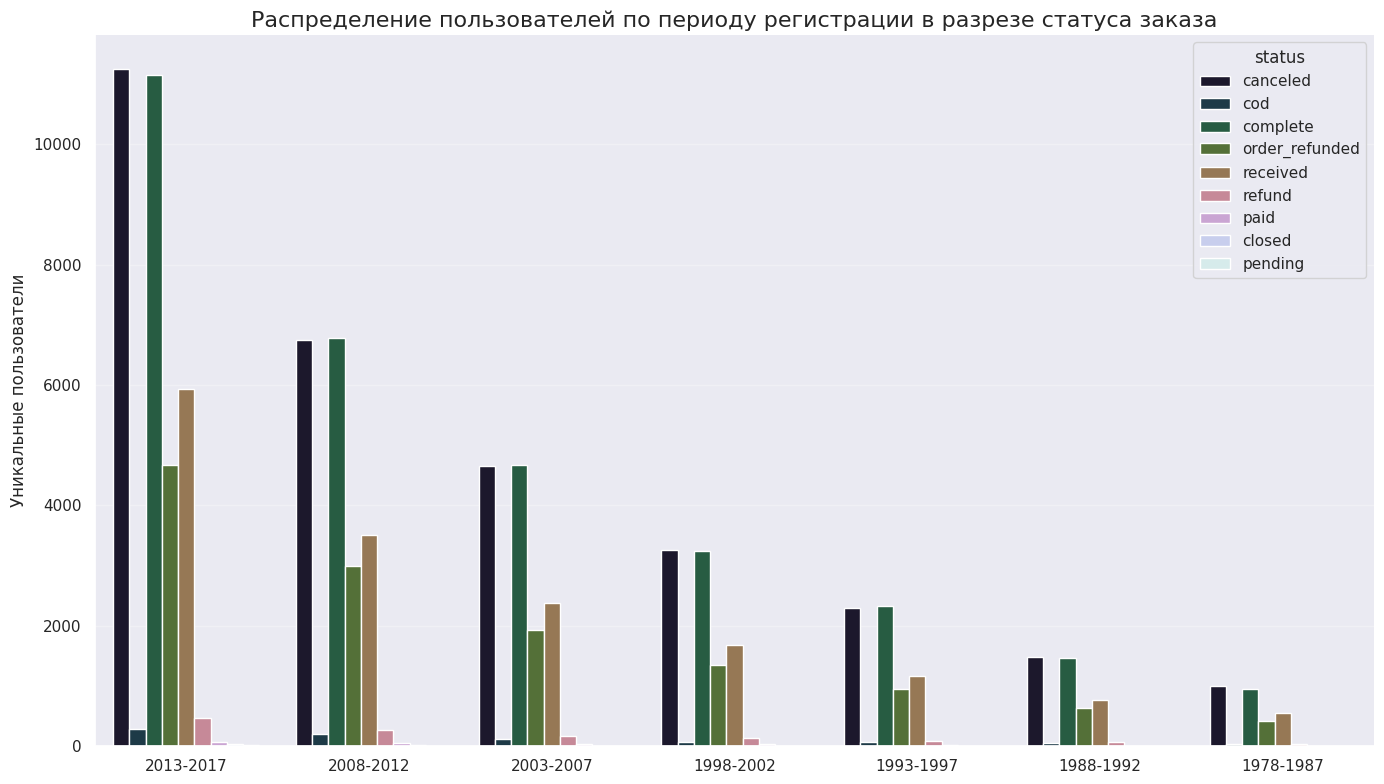

In [27]:
sns.barplot(data=users_in_period, x='reg_period', y='cust_id', hue='status', order=sorted_period, palette='cubehelix')
plt.title('Распределение пользователей по периоду регистрации в разрезе статуса заказа')
plt.ylabel('Уникальные пользователи')
plt.xlabel('')
plt.tight_layout()
plt.show()

Из графика видно, что доли статусов заказов сохраняются для всех периодов регистрации и дата регистрации не влияет на отмену/возврат/получение заказа.

In [28]:
total_users = orders.groupby('reg_period', observed=True)['cust_id'].nunique()
segments_cohort = orders.groupby(['reg_period', 'order_month'], as_index=False, observed=True)['cust_id'].nunique()

segments_cohort_pivot = pd.pivot_table(data=segments_cohort, index='reg_period', columns='order_month', values='cust_id', observed=True)
segments = segments_cohort_pivot.divide(total_users, axis=0).sort_index()

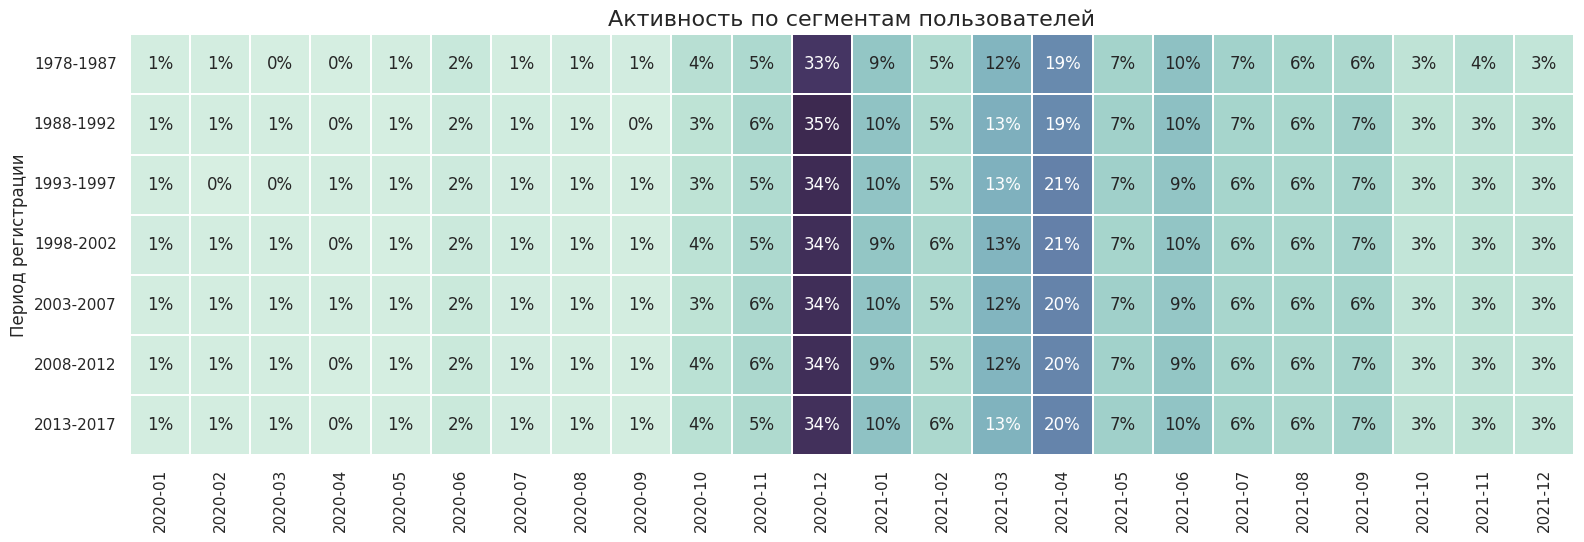

In [29]:
plt.figure(figsize=(16,14))
sns.heatmap(data=segments, annot=True, fmt='.0%', cbar=False, square=True, linewidth=.3, cmap=cubehelix_cmap)
plt.title('Активность по сегментам пользователей')
plt.ylabel('Период регистрации')
plt.xlabel('')
plt.tight_layout()
plt.show()

Разделение пользователей на периоды показало, что вне зависимости от даты регистрации/первой покупки все сегменты проявляют примерно одинаковую активность. Можно сказать, что все сегменты подчиняются одним и тем же факторам "сезонности" и/или внешним факторам.

Результаты подтвержают диагональную активность прошлого анализа. Здесь также можно заметить, что наиболее активны пользователи в период с 11.2020 по 09.2021 с пиками в 12.2020 и 04.2021. После 04.2021 происходит постепенное снижение интереса к продукту, что может быть обусловлено сезонностью продукта или угасанием эффекта от скидок.

Есть предположение, что 12.2020 произошло улучшение в бизнесе, которое увеличило заинтересованность пользователей в продукте, с поправкой на сезонность, которая, разумеется, тоже может присутствовать в декабре.

#### Интервалы между покупками и средний чек

In [30]:
time_between_orders = complete_orders.sort_values(['cust_id', 'order_date']).copy()

time_between_orders['prev_order_date'] = time_between_orders.groupby('cust_id')['order_date'].shift(1)
time_between_orders['days_between'] = (time_between_orders['order_date'] - time_between_orders['prev_order_date']).dt.days

tbo_df = time_between_orders[time_between_orders['days_between'].notnull()]['days_between']

print('Медианный интервал между заказами:', round(tbo_df.median()))

Медианный интервал между заказами: 0


In [31]:
tbo_df.describe()

count    34144.000000
mean        22.501757
std         53.356182
min          0.000000
25%          0.000000
50%          0.000000
75%         11.000000
max        628.000000
Name: days_between, dtype: float64

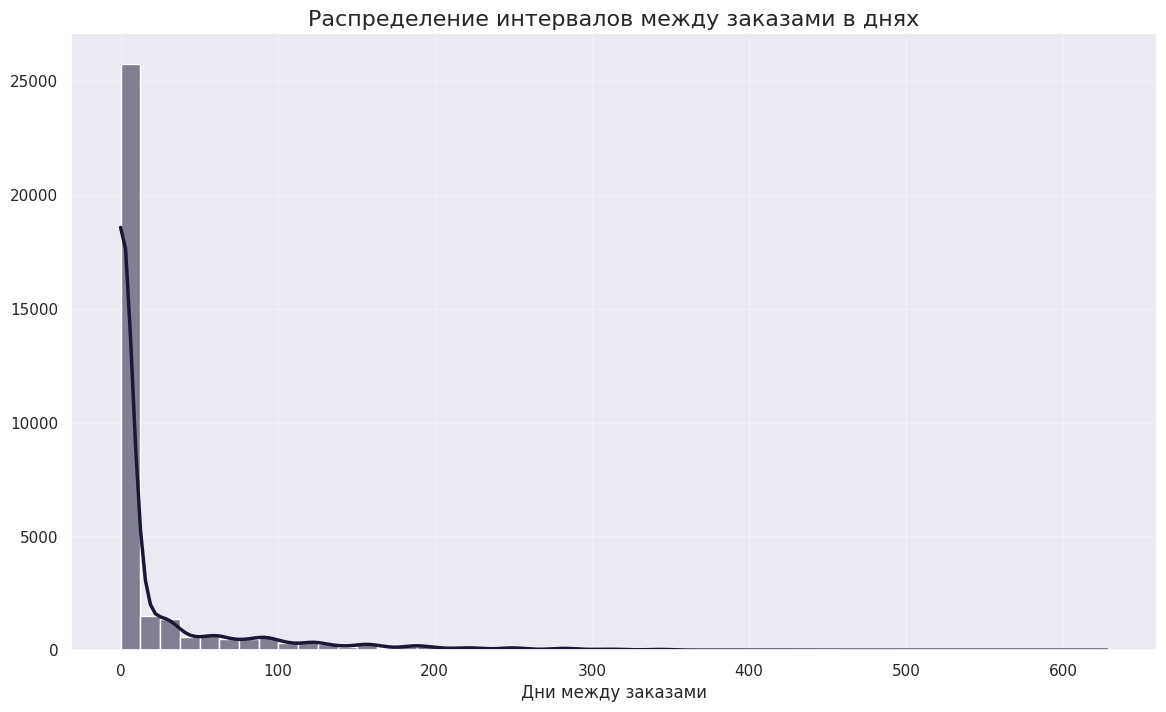

In [32]:
sns.histplot(tbo_df, bins=50, kde=True)
plt.title('Распределение интервалов между заказами в днях')
plt.ylabel('')
plt.xlabel('Дни между заказами')
plt.show()

In [33]:
tbo_diff_days = tbo_df[tbo_df > 0]

print('Медианный интервал между заказами в разные дни:', round(tbo_diff_days.median()))

Медианный интервал между заказами в разные дни: 20


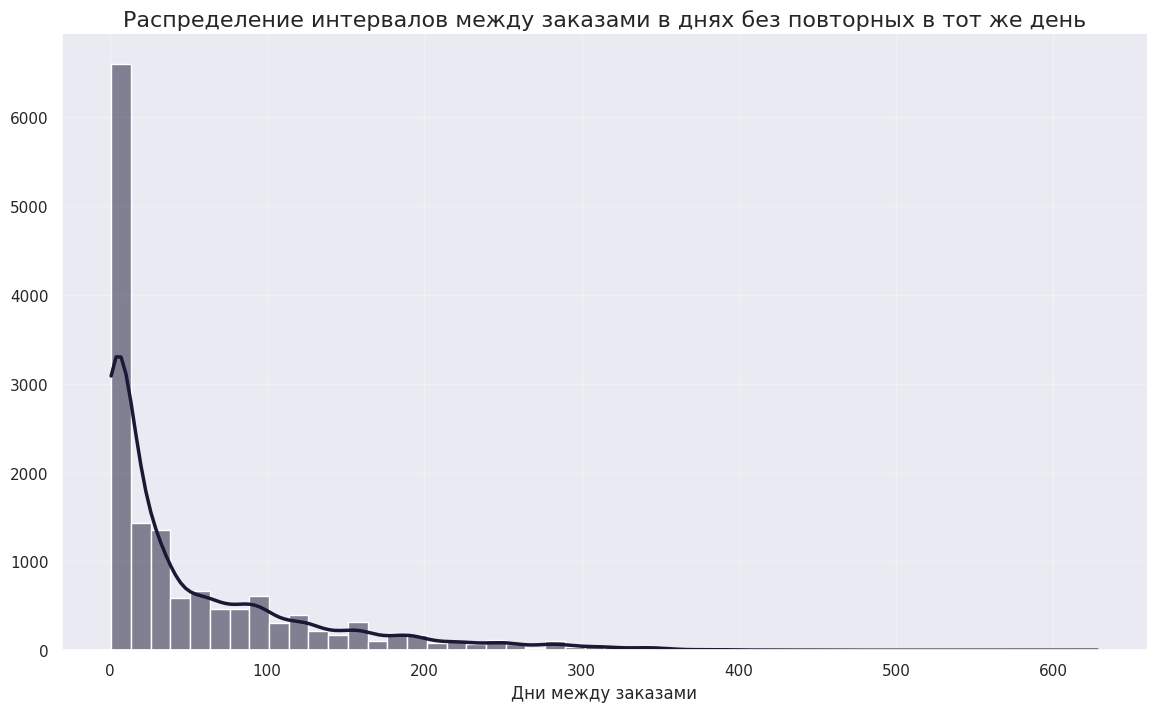

In [34]:
sns.histplot(tbo_diff_days, bins=50, kde=True)
plt.title('Распределение интервалов между заказами в днях без повторных в тот же день')
plt.ylabel('')
plt.xlabel('Дни между заказами')
plt.show()

Медианный интервал между покупками равен 0 дням, что говорит о том, что больше 50% пользователей совершают дополнительные заказы в тот же день, после оформления первого заказа. При исключении покупок в тот же день, медианный интервал составляет 20 дней и распределение данных показывает высокую концентрацию покупок в первые 20 дней после оформления первого заказа.

Этот вывод частично подтверждает результаты когортного анализа, где 96,4% пользователей не оформляют заказ в следующем месяце. Оказалось, что большинство пользователей делает повторные заказы в течение одного месяца.

Посмотрим на средний чек, среднее количество товаров в заказе и долю скидок в объеме заказа. 

In [35]:
complete_orders['has_discount'] = complete_orders['total_discount'] > 0

complete_orders_per_months = complete_orders.groupby('order_month', as_index=False).agg(
    revenue=('total_amount','sum'),
    cnt_orders=('order_id','nunique'),
    total_qty=('total_qty', 'sum'),
    total_discount=('total_discount', 'sum'),
    total_amount_wout_discount=('total_amount_wout_discount', 'sum'))

complete_orders_per_months['avg_discount'] = (complete_orders_per_months['total_discount'] / 
                                              complete_orders_per_months['total_amount_wout_discount'])
complete_orders_per_months['aov_per_month'] = complete_orders_per_months['revenue'] / complete_orders_per_months['cnt_orders']
complete_orders_per_months['avg_qty'] = complete_orders_per_months['total_qty'] / complete_orders_per_months['cnt_orders']
complete_orders_per_months['order_month_str'] = complete_orders_per_months['order_month'].astype(str)

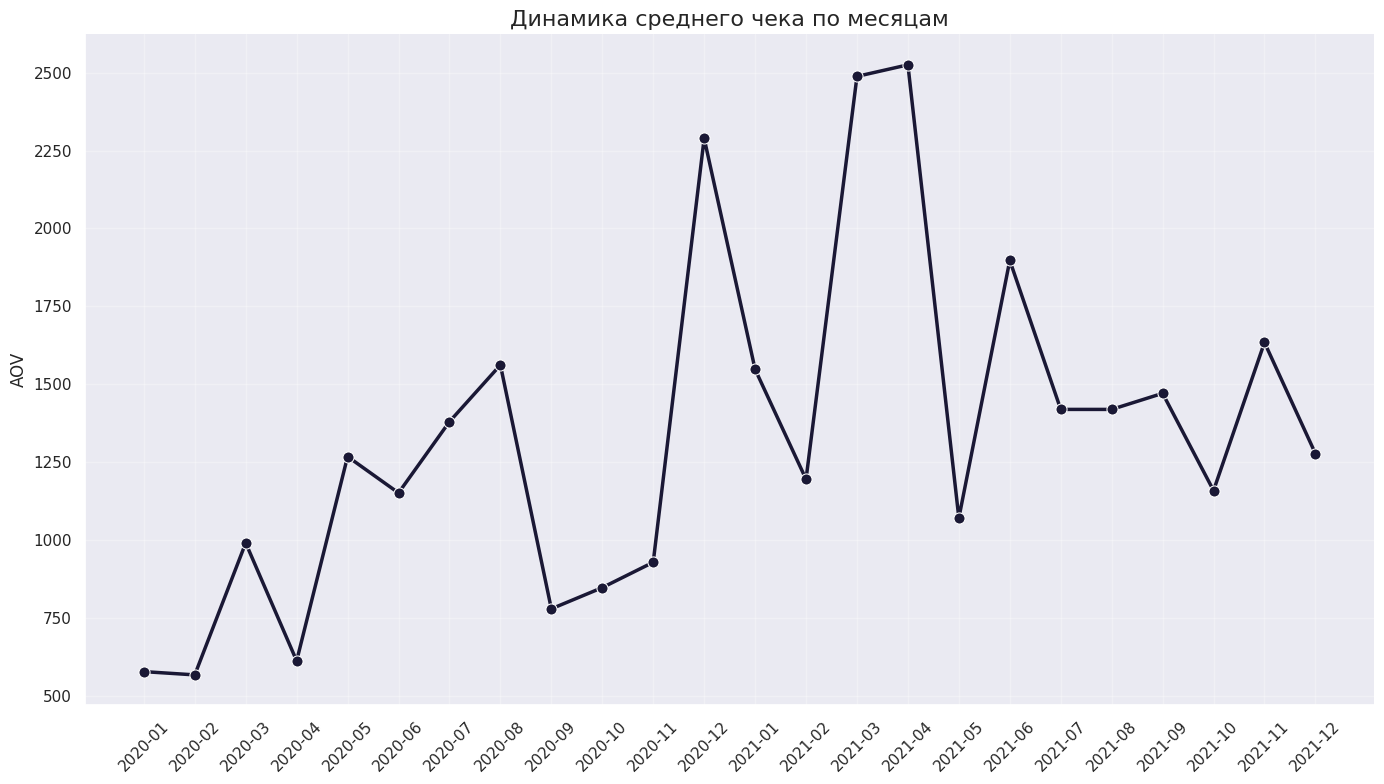

In [36]:
sns.lineplot(data=complete_orders_per_months, x='order_month_str', y='aov_per_month', marker='o')
plt.title('Динамика среднего чека по месяцам')
plt.ylabel('AOV')
plt.xlabel('')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

На графике видно, что с 12.2020 произошло резкое увеличение AOV, что может свидетельствовать о положительных измененениях в продукте.

Это коррелирует с выводом о том, что 12.2020 произошло некое улучшении в бизнесе. За исследуемый период, средний чек в целом растет, однако график очень нестабильный, что может говорить о том, что у бизнеса нет стабильной структуры продаж и каждый месяц средний чек зависит от внешних факторов, а не от естественного поведения аудитории.

In [37]:
aov_comparison = complete_orders.groupby(['order_month', 'has_discount'], as_index=False)['total_amount'].mean()

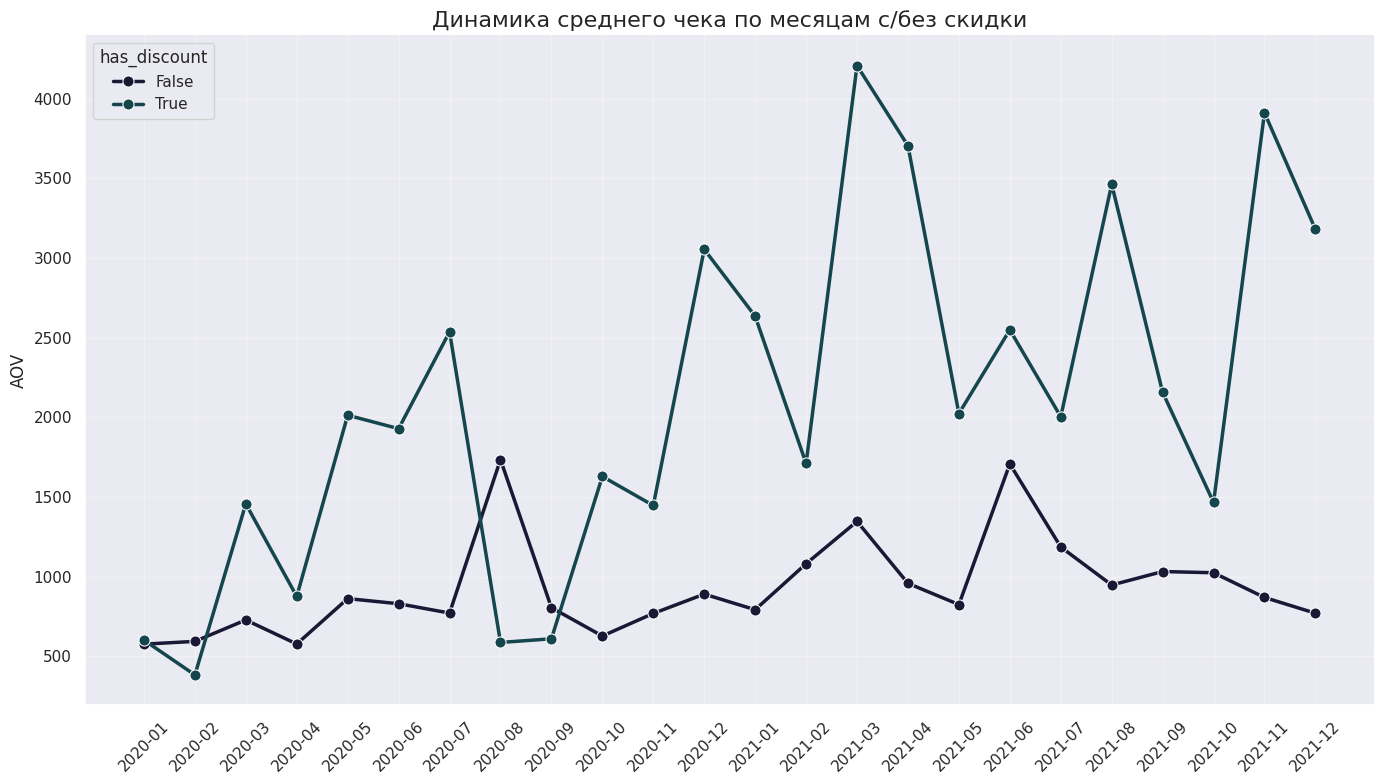

In [38]:
sns.lineplot(data=aov_comparison.assign(order_month=aov_comparison['order_month'].astype(str)), \
            x='order_month', y='total_amount', hue='has_discount', marker='o')
plt.title('Динамика среднего чека по месяцам с/без скидки')
plt.ylabel('AOV')
plt.xlabel('')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Сравнивая значения AOV со скидкой и без нее, можно сделать вывод, что пользователи покупают более дорогие товары или большее количество позиций, привлеченные скидкой. Также можно заметить, что у среднего чека со скидкой можно наблюдать тренд к росту, тогда как средний чек без скидки в начале исследуемого периода и конце остается примерно на одном уровне.

Стратегия предоставления скидок является критическим фактором роста среднего чека. Заказы со скидкой демонстрируют значительно более высокий AOV, что свидетельствует об эффективности такой стратегии. 

Таким образом, скидка в данном бизнесе выполняет функцию инструмента увеличения выручки, а не снижения маржинальности.

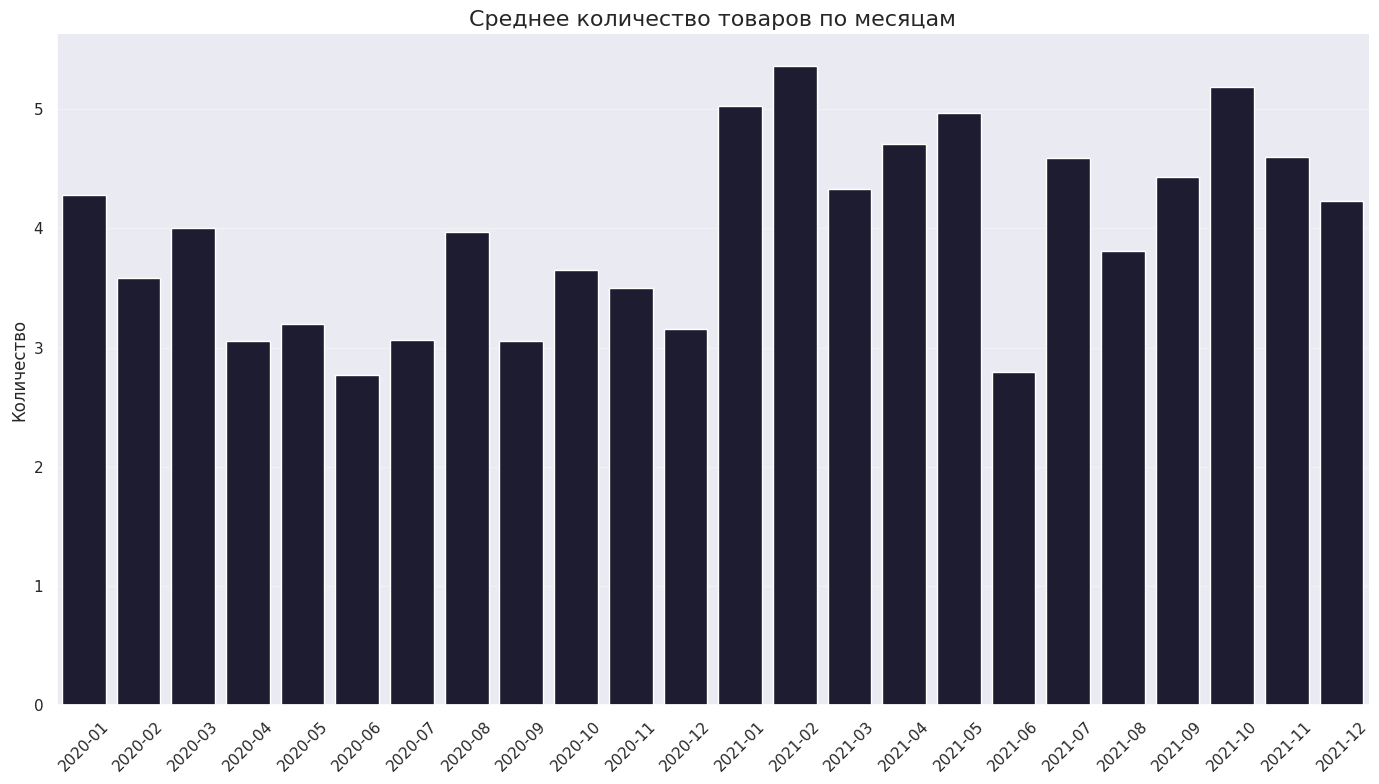

In [39]:
sns.barplot(data=complete_orders_per_months, x='order_month', y='avg_qty')
plt.title('Среднее количество товаров по месяцам')
plt.ylabel('Количество')
plt.xlabel('')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Среднее количество товаров в целом остается стабильным, колеблясь в пределах 3-5. Это означает что рост AOV связан с увеличением стоимости товаров, а не за счет их количества.

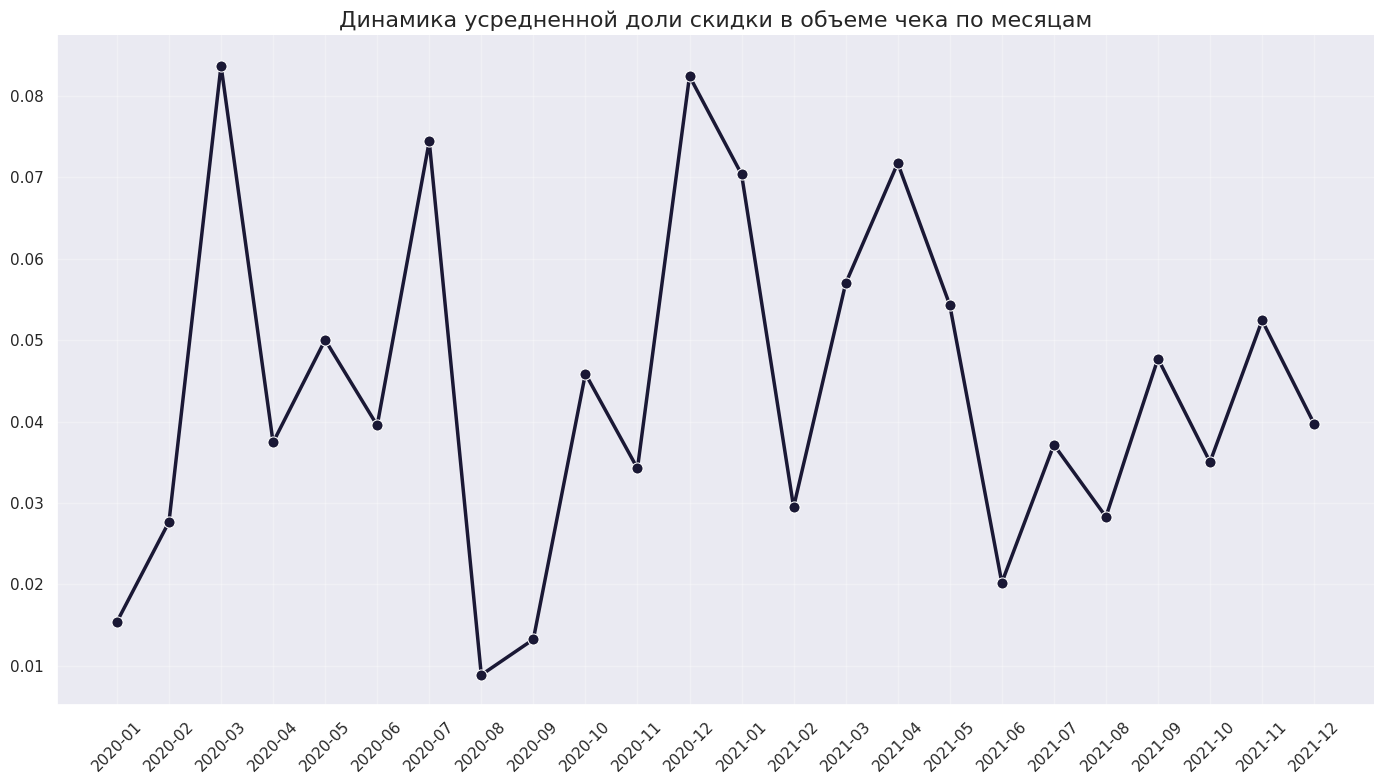

In [40]:
sns.lineplot(data=complete_orders_per_months, x='order_month_str', y='avg_discount', marker='o')
plt.title('Динамика усредненной доли скидки в объеме чека по месяцам')
plt.ylabel('')
plt.xlabel('')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Мы наблюдаем, что доля скидки в объеме чека достигает пиков в 03.2020, 07.2020, 12.2020 и 04.2021, что может говорить о том, что в период новогодних праздников и месяцах, где возможно снижается спрос, компания увеличивает размер скидки и тем самым увеличиливает средний чек, что было замечено на предыдущих графиках.

Текущая стратегия компании носит акционный характер, что позволяет успешно стимулировать спрос, но создает высокую волатильность выручки.

#### Cumulative LTV

In [41]:
cohort_revenue = complete_orders.groupby(['cohort_month', 'cohort_idx'], as_index=False)['total_amount'].sum()
cohort_revenue

,cohort_month,cohort_idx,total_amount
0,2020-01,0,90777.52200
1,2020-01,1,5424.20000
2,2020-01,2,2269.20000
3,2020-01,3,1699.60000
4,2020-01,4,966.00000
...,...,...,...
288,2021-10,0,398953.30498
289,2021-10,1,3156.20000
290,2021-10,2,490.91000
291,2021-11,0,530575.69000


In [42]:
cohort_revenue_pivot = pd.pivot(data=cohort_revenue, index='cohort_month', columns='cohort_idx', values='total_amount')
ltv_mtrx = cohort_revenue_pivot.div(cohort_size, axis=0).cumsum(axis=1)

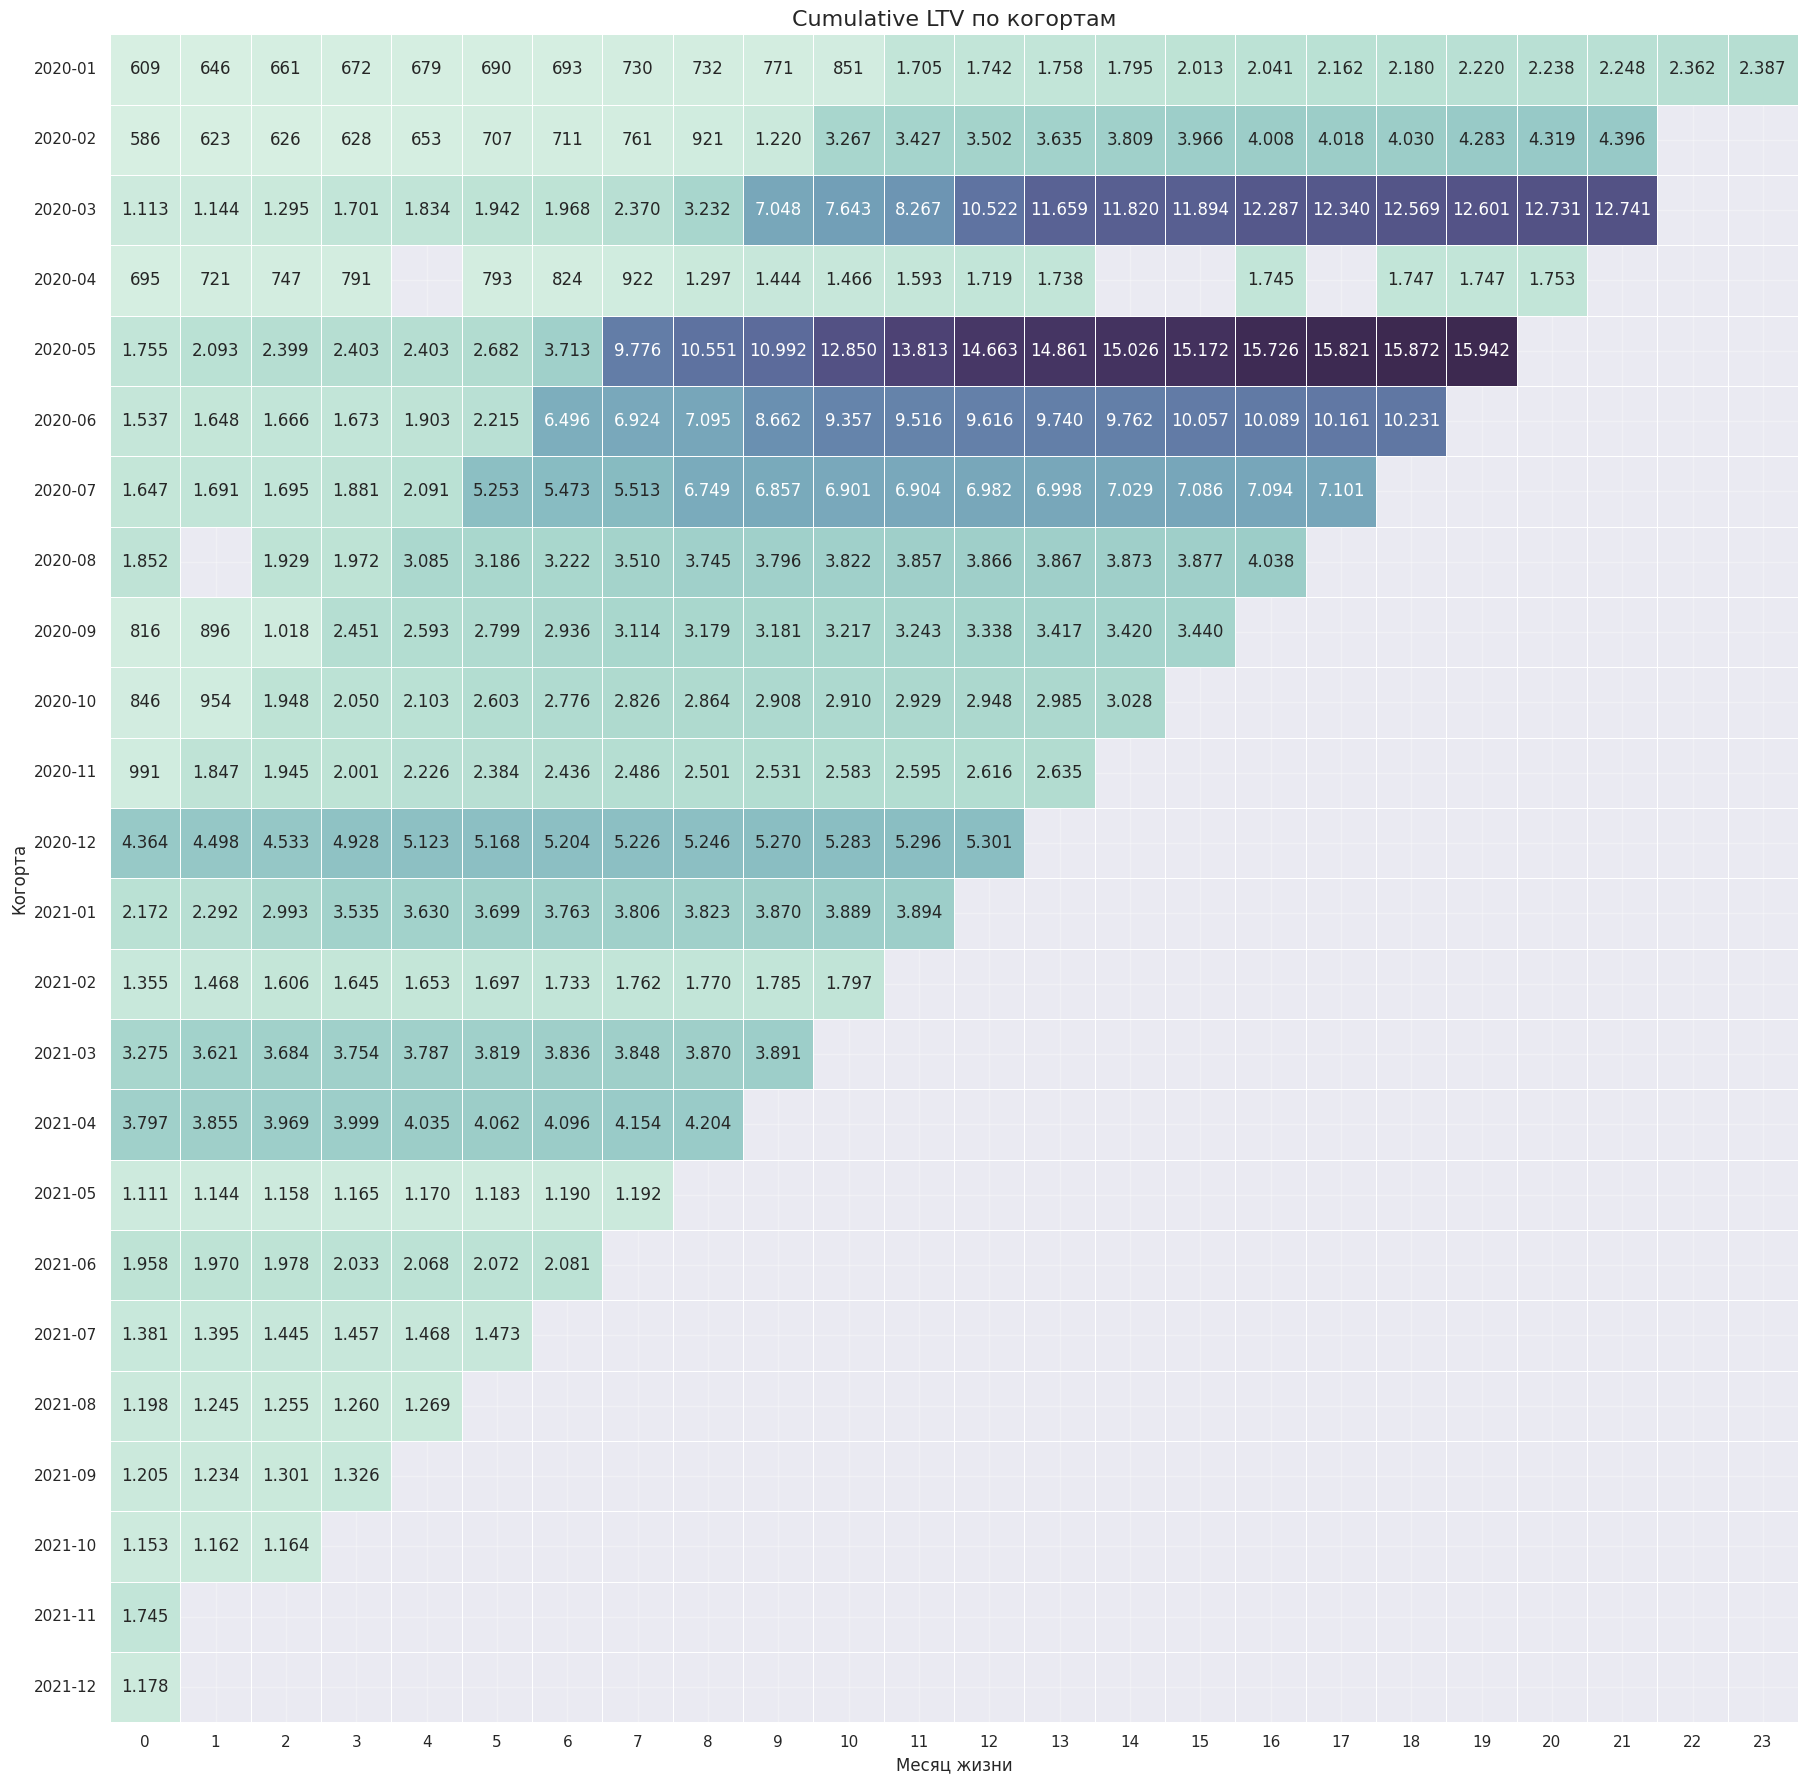

In [43]:
plt.figure(figsize=(20, 18))
sns.heatmap(data=ltv_mtrx, annot=True, fmt='.0f', cbar=False, square=True, linewidth=.4, cmap=cubehelix_cmap)

for t in plt.gca().texts:
    value = float(t.get_text())
    t.set_text(f'{value:,.0f}'.replace(',', '.'))
    
plt.title('Cumulative LTV по когортам')
plt.ylabel('Когорта')
plt.xlabel('Месяц жизни')
plt.tight_layout()
plt.show()

Исследуя LTV по месячным когортам сильно выделяются пользователи, которые сделали первый заказ в периоде 03.2020 и 05.2020. Они не были замечены в предыдущих анализах, однако принесли намного больше накопленной выручки, чем пользователи из остальных когорт. На такую лояльность этой аудитории могли повлиять скидки и/или улучшения бизнеса, которые были в декабре 2020, т.к. именно с декабря когорты резко увеличивают совокупный доход.

Когорта 12.2020, 03.2021, 04,2021 показывает более высокие показатели в первый месяц, что связано с объемом этих когорт. Когорты конца 2020-начала 2021 года показывают высокий LTV в первый месяц, однако последующий рост этих групп крайне мал, что говорит о том, что старая база пользователей была привлечена на старте, но в долгосрочной перспективе не задерживается.

#### Выводы

В анализе рассматривалась база старых пользователей, зарегистрировавшихся в течении 40 лет до 2018 года, и их период активности за 2020-2021 год.

1. Когортный анализ показал, что подавляющее большинство пользователей не возвращаются в продукт и не делают успешные заказы в последующих месяцах. При этом отчетливо прослеживается диагональный эффект, возможно, указывающий на положительное влияние стратегических изменений, внедренных в декабре 2020 года.
2. Сегментный анализ активности пользователей показал, что дата регистрации не влияет на их активность. Все пользователи вне зависимости от периода регистрации стали более активными с декабря 2020 года и снизили активность к концу 2021 года, что может указывать на сильное влияние внешних факторов и маркетинговых активностей на всю базу целиком.
3. Анализ времени между покупками показал следующее поведение аудитории: больше половины делают несколько заказов в один день. Если рассматривать только разные дни, то большинство делает заказы в течение 20 дней с даты прошлого заказа.
4. На графиках со средним чеком и долей скидок в чеке замечено, что средний чек от начала к концу периода в целом имеет тенденцию к росту. В разрезе скидок средний чек по заказам, где скидки были - растет, а где их не было - остается на том же уровне. Компания применяет стратегию промо-акций, позволяющую в периоды затухания спроса стимулировать пользователей делать новые заказы. Эта стратегия имеет ситуативный характер, однако стратегии не хватает регулярности и предсказуемости в скидках.
5. Анализ cumulative LTV показал, что когорты марта и мая 2020 года принесли наибольшее количество совокупного дохода компании, несмотря на их относительно небольшой размер (около 300 пользователей) и пик роста как раз пришелся на декабрь 2020 года. Это свидетельствует об успешной реализации стратегии реактивации аудитории в тот период.

Рекомендуется:
1. Внедрить автоматические рассылки, основываясь на медианном интервале в 20 дней, чтобы напоминать о бренде до того, как клиент окончательно станет inactive, то есть сфокусироваться не на месячном удержании, а на удержании в более малый период.
2. Перейти к более системной модели промо-акций для сглаживания периодов затухания активности/покупок.
3. Внедрить функционал дозаказа (если такого функционала нет), т.к. повторные заказы в один день могут говорить о том, что корзина формирируется в несколько этапов.
4. Детально изучить когорты марта и мая 2020 года и изучить их всплекс активности для того, чтобы применять те же стратегии привлечения для других клиентов.